<a href="https://colab.research.google.com/github/nauerromero/Ciencia_de_Datos_II/blob/main/ArchivosCasoPractico2/CasoPractico2_Colaborativo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cloning into 'Ciencia_de_Datos_II'...
remote: Enumerating objects: 688, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 688 (delta 0), reused 0 (delta 0), pack-reused 683 (from 2)
Receiving objects: 100% (688/688), 192.49 MiB | 16.72 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Updating files: 100% (611/611), done.
/content/Ciencia_de_Datos_II/ArchivosCasoPractico2/dataset_sample/train

 Estructura de directorios:
.: 0 archivos
./NORMAL: 300 archivos

 Clases encontradas: ['NORMAL', 'PNEUMONIA']

 Distribución de imágenes por clase:
 - NORMAL: 300 imágenes
 - PNEUMONIA: 300 imágenes


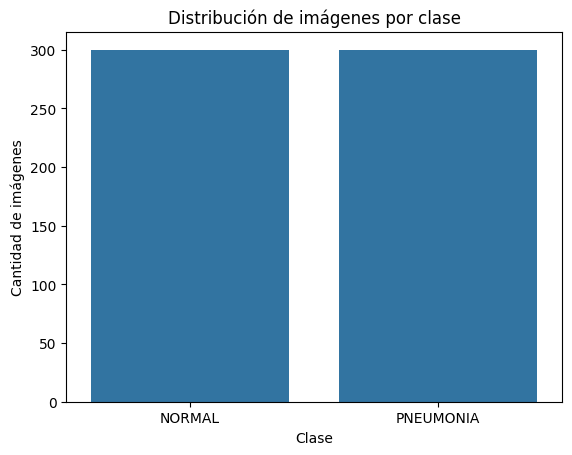

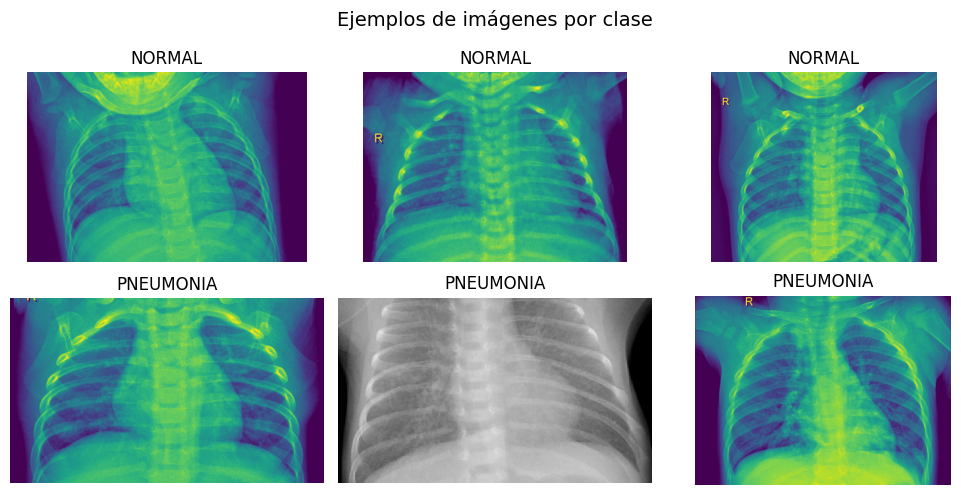


 Dimensiones promedio de las imágenes: 1426.7x1065.4 píxeles


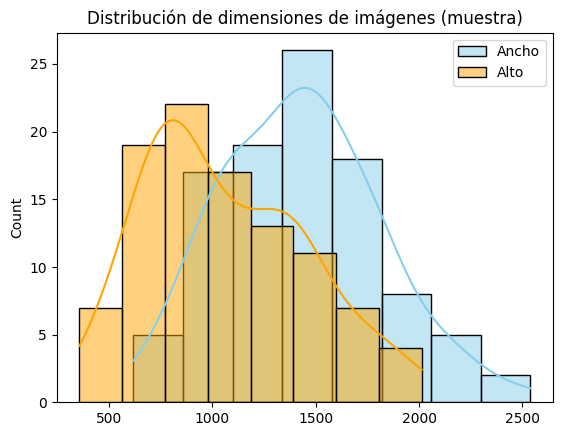


 EDA completado. Continuando con el flujo original...

Found 480 images belonging to 2 classes.
Found 120 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Entrenando Model_1...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1000ms/step - accuracy: 0.5169 - loss: 4.7022 - val_accuracy: 0.6250 - val_loss: 0.7907
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 986ms/step - accuracy: 0.6356 - loss: 0.9865 - val_accuracy: 0.7167 - val_loss: 0.4924
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 884ms/step - accuracy: 0.8305 - loss: 0.4601 - val_accuracy: 0.9000 - val_loss: 0.3572
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 890ms/step - accuracy: 0.8942 - loss: 0.3248 - val_accuracy: 0.8250 - val_loss: 0.3568
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 888ms/step - accuracy: 0.8797 - loss: 0.3001 - val_accuracy: 0.9250 - val_loss: 0.2474

Entrenando Model_2...
Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5298 - loss: 3.9311 - val_accuracy: 0.5000 - val_loss: 0.9209
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6544 - loss: 0.7437 - val_accuracy: 0.7917 - val_loss: 0.4507
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8320 - loss: 0.3943 - v

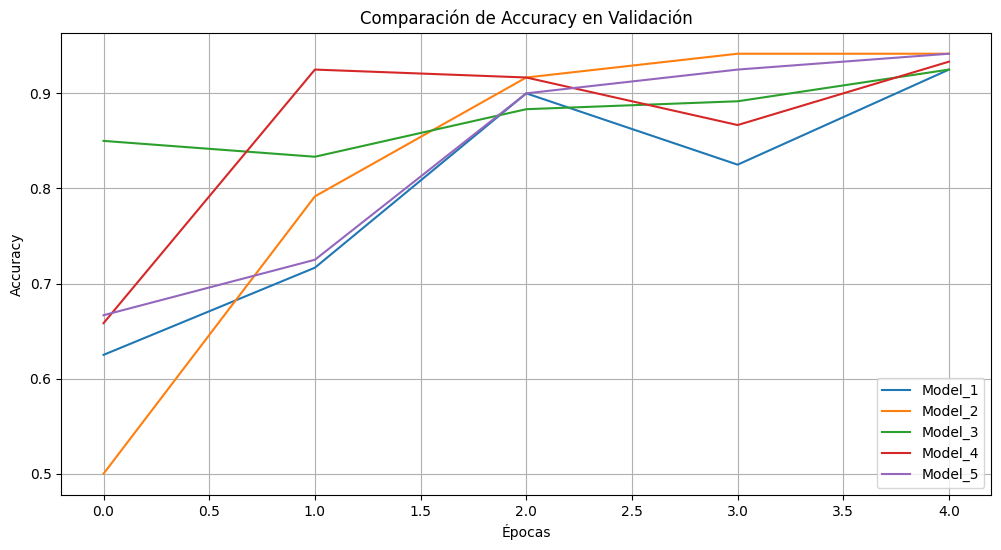

Entrenamiento completado. Los modelos fueron calibrados sobre la muestra significativa.
Dataset usado: 300 imágenes por clase (NORMAL vs PNEUMONIA)


In [ ]:
# Requerimiento 1: Cargar el dataset desde GitHub
# Clonamos el repositorio para asegurar trazabilidad y reproducibilidad
!git clone https://github.com/nauerromero/Ciencia_de_Datos_II.git
%cd Ciencia_de_Datos_II/ArchivosCasoPractico2/dataset_sample/train
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Verificar estructura de carpetas
print("\n Estructura de directorios:")
for root, dirs, files in os.walk(".", topdown=True):
    print(f"{root}: {len(files)} archivos")
    if len(files) > 0:
        break  # Solo mostrar un nivel de profundidad

# Clases disponibles (ej. NORMAL y PNEUMONIA)
classes = [d for d in os.listdir('.') if os.path.isdir(d)]
print("\n Clases encontradas:", classes)

# Contar cantidad de imágenes por clase
counts = {cls: len(os.listdir(os.path.join('.', cls))) for cls in classes}
print("\n Distribución de imágenes por clase:")
for k, v in counts.items():
    print(f" - {k}: {v} imágenes")

# Visualizar la distribución con gráfico de barras
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.title('Distribución de imágenes por clase')
plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.show()

# Mostrar algunas imágenes de ejemplo
plt.figure(figsize=(10,5))
for i, cls in enumerate(classes):
    class_path = os.path.join('.', cls)
    sample_imgs = os.listdir(class_path)[:3]  # Muestra 3 ejemplos por clase
    for j, img_name in enumerate(sample_imgs):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        plt.subplot(len(classes), 3, i*3 + j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{cls}")
plt.suptitle("Ejemplos de imágenes por clase", fontsize=14)
plt.tight_layout()
plt.show()

# Comprobar dimensiones promedio de las imágenes
heights, widths = [], []
for cls in classes:
    class_path = os.path.join('.', cls)
    sample_imgs = os.listdir(class_path)[:50]  # Tomar muestra
    for img_name in sample_imgs:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"\n Dimensiones promedio de las imágenes: {np.mean(widths):.1f}x{np.mean(heights):.1f} píxeles")
sns.histplot(widths, kde=True, color='skyblue', label='Ancho')
sns.histplot(heights, kde=True, color='orange', label='Alto')
plt.title('Distribución de dimensiones de imágenes (muestra)')
plt.legend()
plt.show()

print("\n EDA completado. Continuando con el flujo original...\n")

# Requerimiento 2: Cargar imágenes desde la muestra significativa
# Usamos ImageDataGenerator para cargar 300 imágenes por clase desde la carpeta 'train'
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    directory='.',  # Este punto indica que estamos dentro de 'train'
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    directory='.',  # Este punto indica que estamos dentro de 'train'
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

# Requerimiento 3: Aplicar cinco algoritmos de ML con una sola capa convolucional
# Se aplican cinco CNNs con una sola capa convolucional, seguidas por capas densas y dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_model(filters, dense_units, dropout_rate):
    model = Sequential([
        Conv2D(filters, (3,3), activation='relu', input_shape=(150,150,3)),  # Capa convolucional única
        MaxPooling2D(2,2),
        Flatten(),
        Dense(dense_units, activation='relu'),  # Capa densa adicional
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')  # Salida binaria: NORMAL vs PNEUMONIA
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Configuraciones aplicadas:
# Model_1: 16 filtros, 64 unidades densas, dropout 0.3
# Model_2: 32 filtros, 128 unidades densas, dropout 0.4
# Model_3: 64 filtros, 256 unidades densas, dropout 0.5
# Model_4: 32 filtros, 64 unidades densas, dropout 0.2
# Model_5: 16 filtros, 128 unidades densas, dropout 0.3

configs = [
    (16, 64, 0.3),
    (32, 128, 0.4),
    (64, 256, 0.5),
    (32, 64, 0.2),
    (16, 128, 0.3)
]

models = [build_model(*cfg) for cfg in configs]
names = [f"Model_{i+1}" for i in range(len(models))]

# Requerimiento 4: Entrenar modelos y comparar desempeño
# Se entrena cada modelo y se guarda su historial para comparar accuracy en validación
histories = []
for i, model in enumerate(models):
    print(f"\nEntrenando {names[i]}...")
    history = model.fit(train_gen, validation_data=val_gen, epochs=5, verbose=1)
    histories.append(history)

# Requerimiento 5: Identificar mejoras o debilidades entre modelos
# Se visualiza el accuracy en validación para cada modelo, permitiendo comparar desempeño
plt.figure(figsize=(12,6))
for i, history in enumerate(histories):
    plt.plot(history.history['val_accuracy'], label=f'{names[i]}')
plt.title('Comparación de Accuracy en Validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


print("Entrenamiento completado. Los modelos fueron calibrados sobre la muestra significativa.")
print("Dataset usado: 300 imágenes por clase (NORMAL vs PNEUMONIA)")


Guardando y probar Modelo


Mejor modelo: Model_2 con accuracy de validación = 0.9417
Modelo guardado como Model_2.h5


Modelo cargado exitosamente para predicción dinámica.


Saving WhatsApp Image 2025-10-24 at 18.39.17_cb25b983.jpg to WhatsApp Image 2025-10-24 at 18.39.17_cb25b983 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


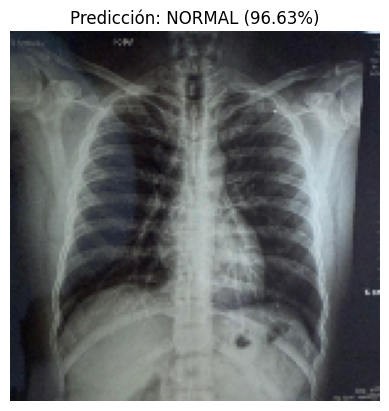

 Resultado: NORMAL (confianza: 96.63%)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from google.colab import files

# Identificar el mejor modelo según accuracy de validación final
val_accuracies = [h.history['val_accuracy'][-1] for h in histories]
best_index = np.argmax(val_accuracies)
best_model = models[best_index]
best_name = names[best_index]
best_acc = val_accuracies[best_index]

print(f"\nMejor modelo: {best_name} con accuracy de validación = {best_acc:.4f}")

# Guardar el mejor modelo en formato HDF5
best_model.save(f"{best_name}.h5")
print(f"Modelo guardado como {best_name}.h5")

# Cargar el modelo guardado (simulación de reutilización futura)
model_loaded = load_model(f"{best_name}.h5")
print("Modelo cargado exitosamente para predicción dinámica.")

# Función para predecir una imagen dinámica (entrada del usuario)
def predecir_imagen(ruta_imagen):
    """
    Carga una imagen externa, la procesa y predice su clase (NORMAL o PNEUMONIA).
    """
    img = image.load_img(ruta_imagen, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediccion = model_loaded.predict(img_array)[0][0]
    clase_predicha = 'PNEUMONIA' if prediccion > 0.5 else 'NORMAL'
    prob = prediccion if prediccion > 0.5 else (1 - prediccion)

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicción: {clase_predicha} ({prob*100:.2f}%)")
    plt.show()

    print(f" Resultado: {clase_predicha} (confianza: {prob*100:.2f}%)")

# Prueba dinámica
# Solo asegúrate de que sea del mismo tipo que el dataset (radiografía de tórax)
uploaded = files.upload()

ruta_imagen = list(uploaded.keys())[0]


predecir_imagen(ruta_imagen)
